<a href="https://colab.research.google.com/github/karthikoo7/Machine_Learning-BDA-/blob/main/Clustering_Algo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Day 2 - Unsupervised Learning


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



In [ ]:
df = pd.read_csv("sample_1.csv")

In [ ]:
df.shape

(300, 2)

In [ ]:
df.isna().sum()

,0
c1,0
c2,0


In [ ]:
df.dtypes

,0
c1,float64
c2,float64


In [ ]:
df.drop_duplicates(inplace=True)
df.shape

(300, 2)

# Not recommended to do Standardization before K-Means.
Takes extra time for clustering if data is stanadradzied before.

In [ ]:
X = df

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test = train_test_split(X,test_size=0.3,random_state=101)

X_train.shape,X_test.shape

((210, 2), (90, 2))

In [ ]:
from sklearn.cluster import KMeans

KMeans Clustering on data

In [ ]:
# Step1 - create  object
# Step - 2 call fit function
# Step -3 then predict
km = KMeans(n_clusters=3,max_iter=100,random_state=101)
km.fit(X_train) # fit means training


KMeans(max_iter=100, n_clusters=3, random_state=101)

In [ ]:
km.cluster_centers_

array([[-2.65194547,  8.94060751],
       [-6.81196229, -6.95239376],
       [ 4.80763699,  1.8904575 ]])

In [ ]:
y_pred = km.predict(X_test)

/tmp/ipykernel_2207/2011251479.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(df.iloc[:, 0], df.iloc[:, 1],cmap='viridis')


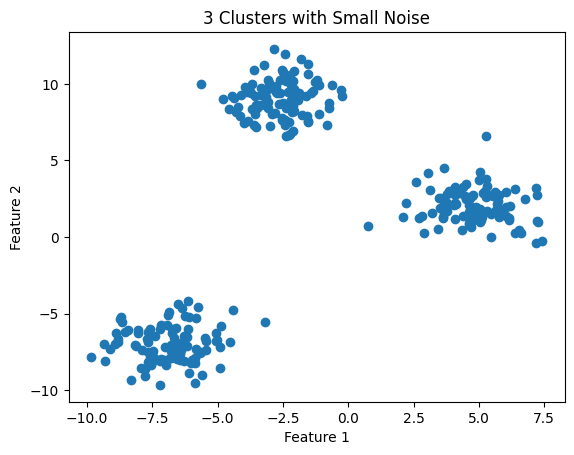

In [ ]:
# Plot
plt.scatter(df.iloc[:, 0], df.iloc[:, 1],cmap='viridis')

plt.title("3 Clusters with Small Noise")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

How we decide the right k in k-means?
-> We use somthing known as l-bow method.


In [ ]:
inertia_values = []
for k in range(2,11):
    mykmeans = KMeans(k,random_state=7)
    mykmeans.fit(X_train)
    inertia_values.append(mykmeans.inertia_)

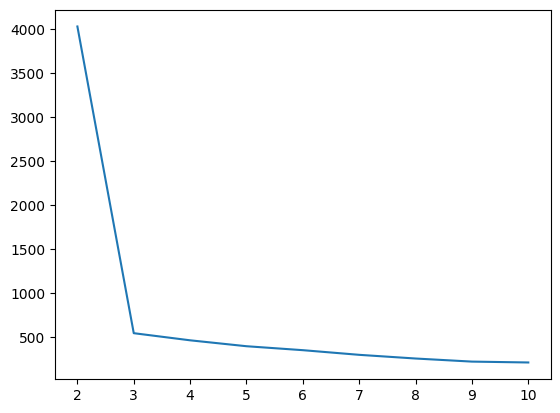

In [ ]:
import matplotlib.pyplot as plt
plt.plot(list(range(2,11)), inertia_values) # looking for angle close to 90

In [ ]:
from sklearn.metrics import silhouette_score


In [ ]:
# two parametres to silhouette score
# X : X_test data
# labels : cluster numbers predicted by the algorithm

km = KMeans(n_clusters=3,max_iter=100,random_state=101)
km.fit(X_train) # fit means training
y_pred = km.predict(X_test)
silhouette_score(X_test,y_pred)

np.float64(0.8036022891725136)

Agglomerative clustering


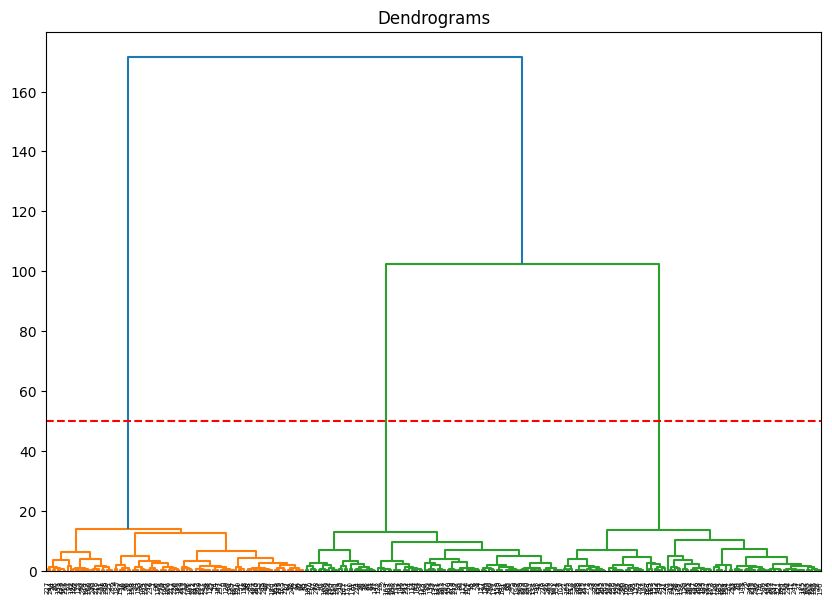

In [53]:
import matplotlib.pyplot as plt

import scipy.cluster.hierarchy as shc
plt.figure(figsize=(10, 7))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(X.iloc[:500,:], method='ward'))
plt.axhline(y=50, color='r', linestyle='--')

In [49]:
from sklearn.cluster import AgglomerativeClustering

In [51]:
ac = AgglomerativeClustering(n_clusters=3)
ac.fit(X_train)
#y_pred = ac.predict() # Not present !! i.e cannot predict on new data.
y_pred = ac.fit_predict(X_train)

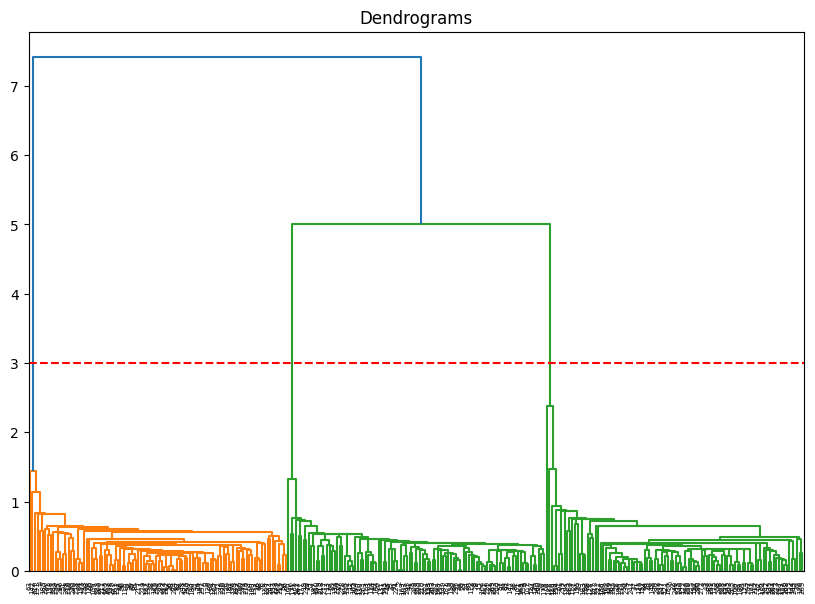

In [58]:
import matplotlib.pyplot as plt

import scipy.cluster.hierarchy as shc
plt.figure(figsize=(10, 7))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(X.iloc[:500,:], method='single'))
plt.axhline(y=3, color='r', linestyle='--')

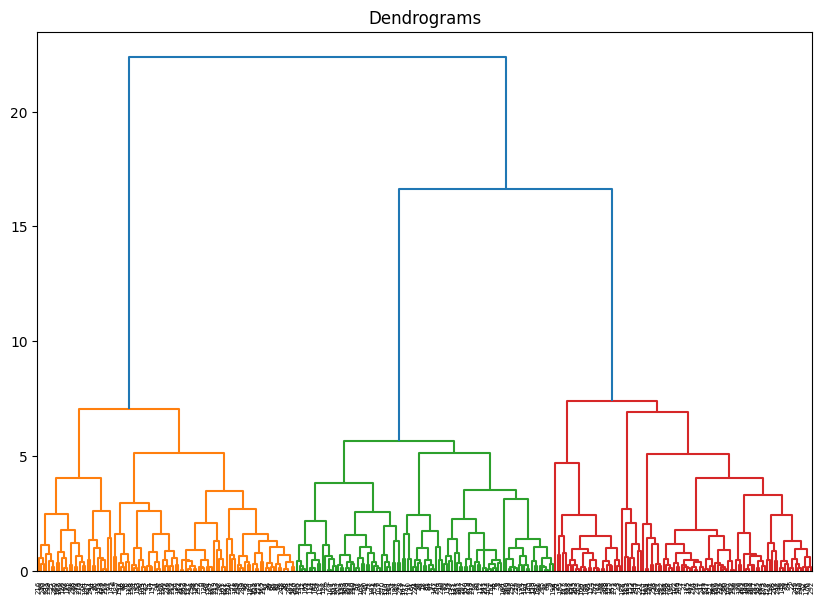

In [55]:
import matplotlib.pyplot as plt

import scipy.cluster.hierarchy as shc
plt.figure(figsize=(10, 7))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(X.iloc[:500,:], method='complete'))
plt.axhline(y=50, color='r', linestyle='--')

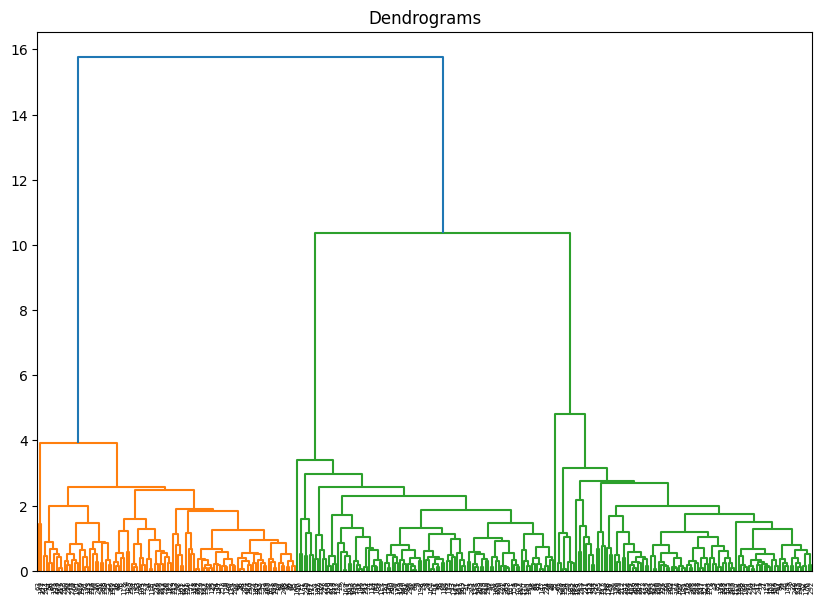

In [56]:
import matplotlib.pyplot as plt

import scipy.cluster.hierarchy as shc
plt.figure(figsize=(10, 7))
plt.title("Dendrograms")
dend = shc.dendrogram(shc.linkage(X.iloc[:500,:], method='average'))
plt.axhline(y=50, color='r', linestyle='--')